# Assignment 6 — Generation Experiment

**DATAX504** · Due end of Week 11

Choose **text** or **image** generation. This notebook is intentionally sparse: pick a small, runnable experiment you can defend in the reflection.

## Tasks
1. Train or adapt a small generator (char-RNN / small LM, GAN, VAE, simple diffusion demo, …)
2. Show **5 samples** in this notebook
3. Name the main **failure mode** you observed
4. After reading the [HF diffusion language models post](https://huggingface.co/blog/ProCreations/diffusion-language-model), write ~150 words on AR vs diffusion trade-offs

## Moodle fields
`a6_repo`, `a6_modality`, `a6_failure`, `a6_diffusion_reflection`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model |OpenAI, GPT-5.6 Sol |
| Used for |Reviewing text generation concepts, explaining code, and checking the assignment workflow. |
| Verified how |I ran the notebook locally and checked the model, loss curves, and five generated samples. |
| Not used for |Inventing results, changing generated outputs, or replacing the execution and verification of the notebook. |


In [2]:
MODALITY = "text"  # "text" or "image" — Moodle a6_modality

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Selected modality:", MODALITY)


Selected modality: text


## Experiment

Implement **one** modality below (remove or ignore the other).

Keep the scope small enough to train on a laptop. Document data source, training setup, and how you sampled outputs.


In [3]:
from pathlib import Path
import re

DATA_URL = "https://s3.amazonaws.com/text-datasets/nietzsche.txt"
path = keras.utils.get_file("nietzsche.txt", origin=DATA_URL)

raw_text = Path(path).read_text(encoding="utf-8").lower()
text = re.sub(r"\s+", " ", raw_text)[:200_000]

print("Characters:", len(text))
print("Preview:", text[:160])

Characters: 200000
Preview: preface supposing that truth is a woman--what then? is there not ground for suspecting that all philosophers, in so far as they have been dogmatists, have faile


In [4]:
# Create a vocabulary and map each character to an integer
chars = sorted(set(text))
char_to_id = {char: i for i, char in enumerate(chars)}
id_to_char = {i: char for i, char in enumerate(chars)}

vocab_size = len(chars)
encoded_text = np.array(
    [char_to_id[char] for char in text],
    dtype=np.int32
)

# Use 40 characters to predict the next character
SEQ_LENGTH = 40
STEP = 3

starts = range(0, len(encoded_text) - SEQ_LENGTH, STEP)

X = np.array(
    [encoded_text[i:i + SEQ_LENGTH] for i in starts],
    dtype=np.int32
)
y = np.array(
    [encoded_text[i + SEQ_LENGTH] for i in starts],
    dtype=np.int32
)

print("Vocabulary size:", vocab_size)
print("X shape:", X.shape)
print("y shape:", y.shape)

example_input = "".join(id_to_char[int(i)] for i in X[0])
example_target = id_to_char[int(y[0])]

print("Example input:", repr(example_input))
print("Next character:", repr(example_target))



Vocabulary size: 51
X shape: (66654, 40)
y shape: (66654,)
Example input: 'preface supposing that truth is a woman-'
Next character: '-'


In [5]:
# Make the experiment reproducible
keras.utils.set_random_seed(42)

model = keras.Sequential([
    keras.Input(shape=(SEQ_LENGTH,), dtype="int32"),
    layers.Embedding(input_dim=vocab_size, output_dim=32),
    layers.LSTM(64),
    layers.Dense(vocab_size, activation="softmax")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 40, 32)         │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 51)             │         3,315 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,779 (116.32 KB)

 Trainable params: 29,779 (116.32 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Split by position in the original text
split_position = int(len(encoded_text) * 0.9)

sample_starts = np.arange(
    0, len(encoded_text) - SEQ_LENGTH, STEP
)

train_mask = sample_starts + SEQ_LENGTH < split_position
val_mask = sample_starts >= split_position

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

# Stop if validation loss stops improving
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=8,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping]
)

Training samples: 59987
Validation samples: 6654
Epoch 1/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.7690 - val_loss: 2.5119
Epoch 2/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.4180 - val_loss: 2.3826
Epoch 3/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.3127 - val_loss: 2.2883
Epoch 4/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.2332 - val_loss: 2.2173
Epoch 5/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.1729 - val_loss: 2.1661
Epoch 6/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.1263 - val_loss: 2.1248
Epoch 7/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.0856 - val_loss: 2.0894
Epoch 8/8
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 2.0501 - val_loss: 2.0582


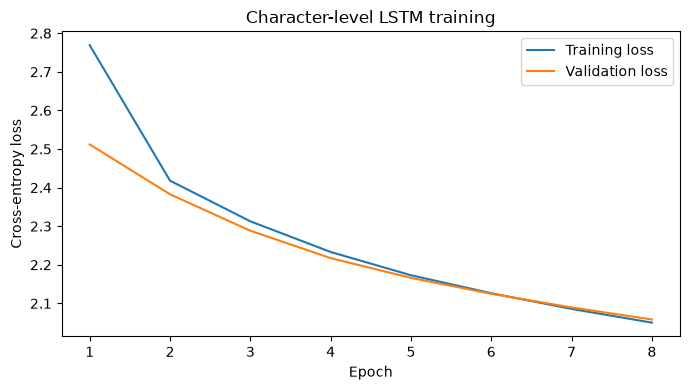

In [7]:
epochs_run = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs_run, history.history["loss"], label="Training loss")
plt.plot(epochs_run, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Character-level LSTM training")
plt.legend()
plt.tight_layout()
plt.show()

model.save("a6_char_lstm.keras")

In [8]:
def generate_text(seed_text, length=300, temperature=0.8, random_seed=42):
    # Keep the most recent 40 characters as context
    context = [
        char_to_id[char]
        for char in seed_text.lower()[-SEQ_LENGTH:]
    ]

    rng = np.random.default_rng(random_seed)
    generated = []

    for _ in range(length):
        inputs = np.array([context], dtype=np.int32)

        # Probability of each possible next character
        probabilities = np.asarray(
            model(inputs, training=False)
        )[0].astype(np.float64)

        # Adjust the distribution using temperature
        logits = np.log(np.clip(probabilities, 1e-8, 1.0))
        logits = logits / temperature
        probabilities = np.exp(logits - np.max(logits))
        probabilities = probabilities / probabilities.sum()

        next_id = int(rng.choice(vocab_size, p=probabilities))
        generated.append(id_to_char[next_id])

        # Add the new character and move the window forward
        context = context[1:] + [next_id]

    return "".join(generated)


# Use one training-text prompt to compare sampling temperatures
seed_text = text[1000:1000 + SEQ_LENGTH]
temperatures = [0.3, 0.5, 0.7, 1.0, 1.2]

samples = []

for i, temperature in enumerate(temperatures, start=1):
    continuation = generate_text(
        seed_text,
        length=300,
        temperature=temperature,
        random_seed=42  # Same random seed for a controlled comparison
    )

    samples.append({
        "temperature": temperature,
        "prompt": seed_text,
        "generated": continuation
    })

    print(f"\nSample {i} | Temperature: {temperature}")
    print("Prompt:", repr(seed_text))
    print("Generated:", continuation)


Sample 1 | Temperature: 0.3
Prompt: 'te philosophical edifices as the dogmati'
Generated: on of the his the serest and the meall in the merel the prear the seal of and the seall and the malle as the the sertion of and and the the prote of and the serest the his the more the selly and and in the condering and in the secention the serith and the secint and and and senting and of the sour t

Sample 2 | Temperature: 0.5
Prompt: 'te philosophical edifices as the dogmati'
Generated: ong at the the ford this cocerts in and of of sere and the conester, in the for the able of the hals this in the porens of the cerestions the vengern to perenting and the noul ore to he mat the chould whace senting the has the prally the all and soment and af and the cail sond the for and the strour

Sample 3 | Temperature: 0.7
Prompt: 'te philosophical edifices as the dogmati'
Generated: ons at the the escopsestime and har and morent evel the in and the faph that the hie bealf somen, ath exsing the of the on ma

## Failure mode (Moodle `a6_failure`)

One short phrase is enough for Moodle (e.g. repetition, mode collapse, blur). Expand briefly below if useful.


*Failure mode observed:*

Main failure mode: repetition at low temperature.

At temperature 0.3, the text often repeated “the” and “and”. Higher temperatures produced more variety, but also more spelling errors and unclear sentences. Although the loss decreased during training, the generated text still lacked meaning.

## AR vs diffusion reflection (Moodle `a6_diffusion_reflection`)

~150 words after the HF reading: compare autoregressive vs diffusion-style generation for *your* modality (quality, control, compute, failure modes).


*Your reflection (~150 words).*

My LSTM generates text one character at a time, using the previous 40 characters. This autoregressive approach was easy to implement and train on my laptop. However, each new character depends on earlier outputs, so mistakes can build up. My samples repeated common words at low temperatures. Higher temperatures increased variety but produced more spelling errors and unclear sentences.

The reading explains that diffusion models generate text by repeatedly removing noise or filling masked positions. They can update several positions together and use context from both sides, which can help with text completion and editing. However, several denoising steps still require computation, so parallel generation is not always faster. Training also involves extra choices, such as the noise or masking schedule.

For this small experiment, autoregressive generation was a practical choice. I did not train a diffusion model, so I cannot say whether it would produce better results on my dataset.